In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


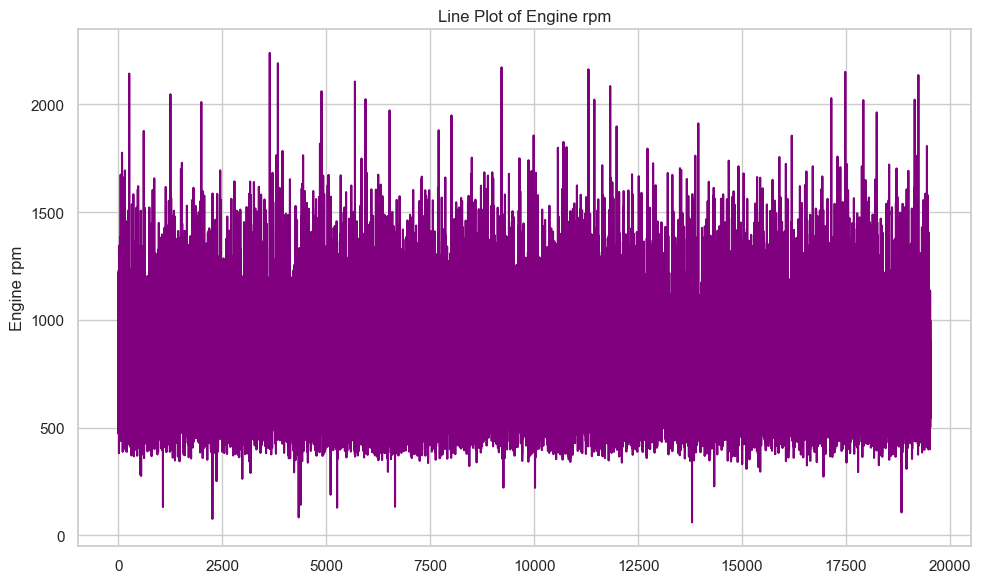

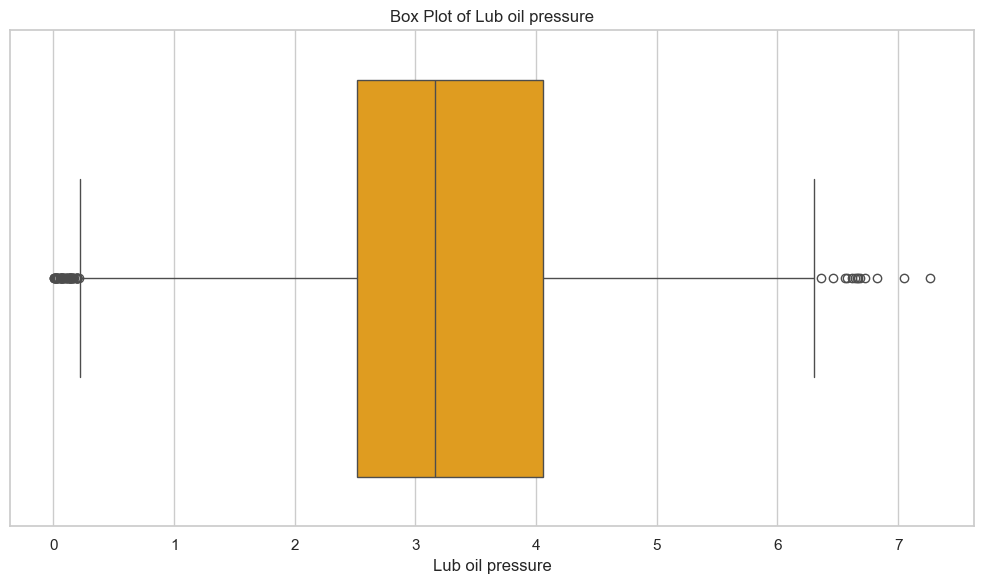

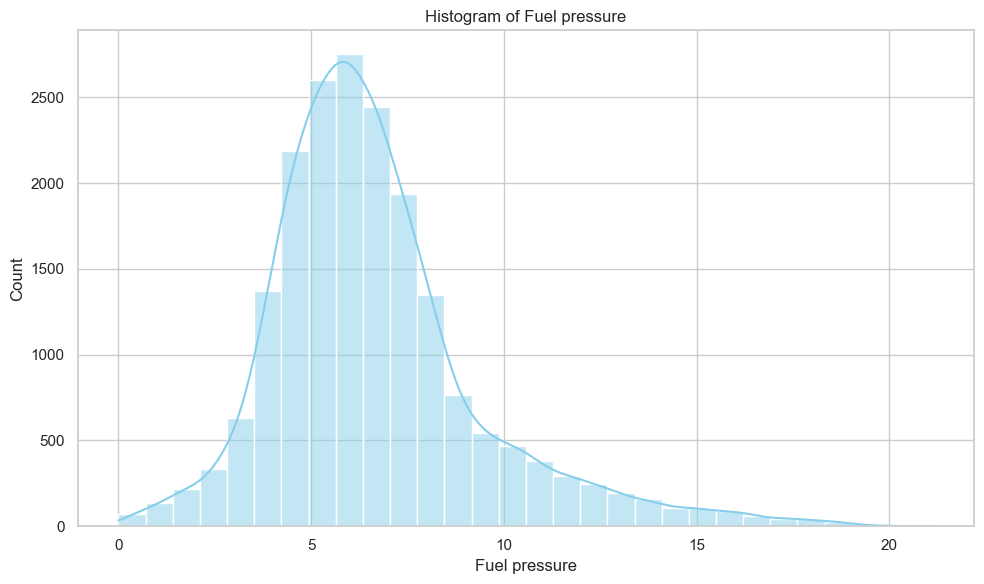

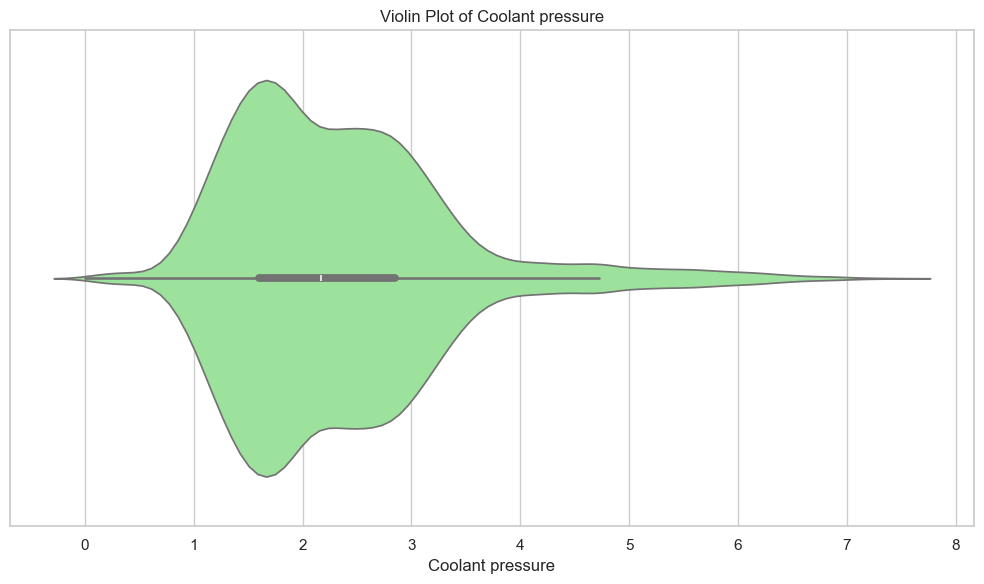

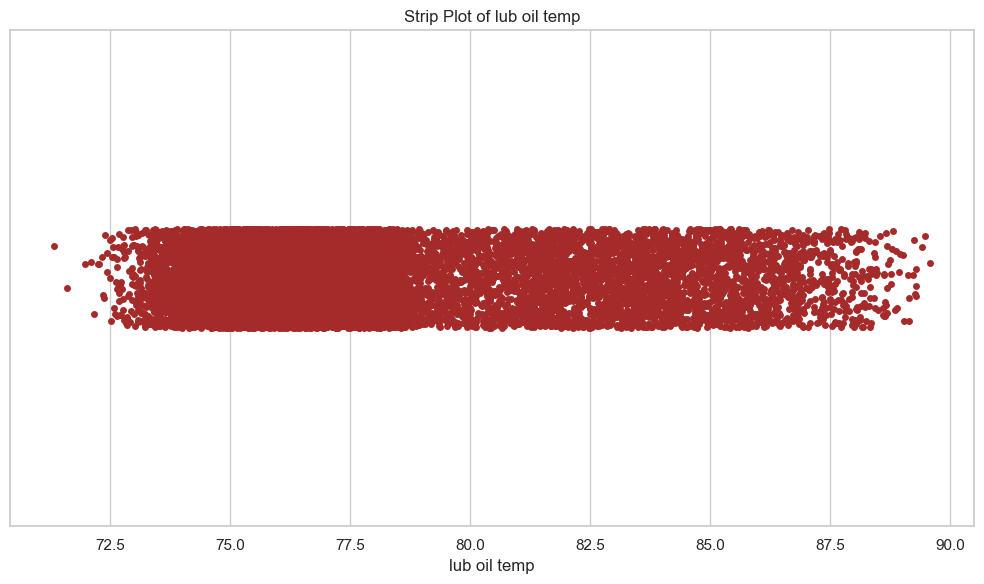

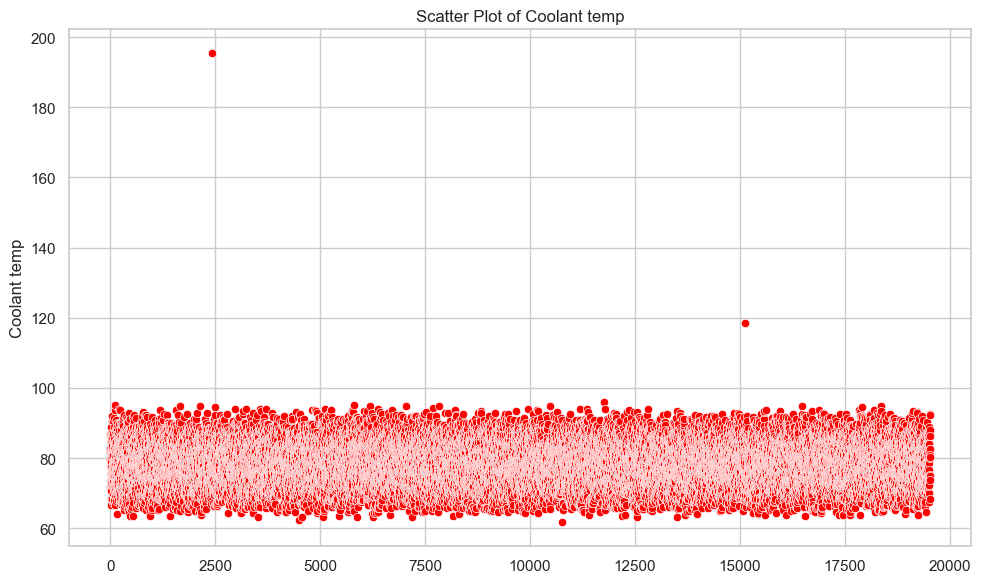

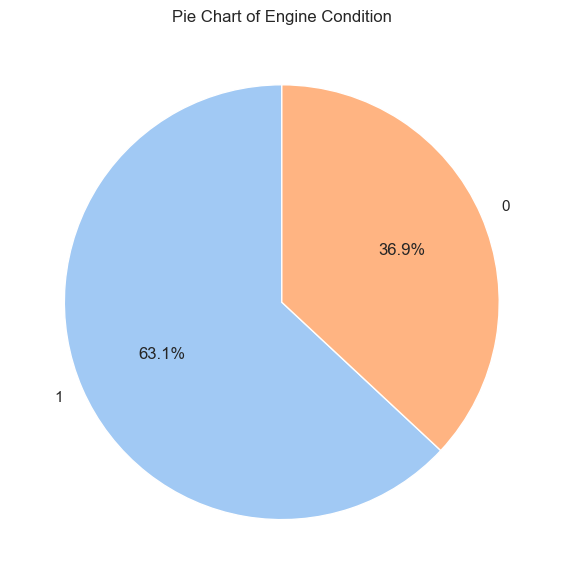

Original class distribution: Counter({1: 12317, 0: 7218})
After SMOTE: Counter({1: 12317, 0: 12317})
Epoch 1/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5246 - loss: 3.1182 - val_accuracy: 0.5640 - val_loss: 2.3246
Epoch 2/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5544 - loss: 2.1542 - val_accuracy: 0.5758 - val_loss: 1.6723
Epoch 3/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5639 - loss: 1.5659 - val_accuracy: 0.5835 - val_loss: 1.2681
Epoch 4/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5819 - loss: 1.2012 - val_accuracy: 0.5837 - val_loss: 1.0276
Epoch 5/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5708 - loss: 0.9934 - val_accuracy: 0.5809 - val_loss: 0.8827
Epoch 6/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5779 - loss: 0.8607 - val_accuracy: 0.5862 - val_loss: 0.7991
Epoch 7/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5825 - loss: 0.7865 - val_accuracy: 0.5876 - val_loss: 0.7489
Epo

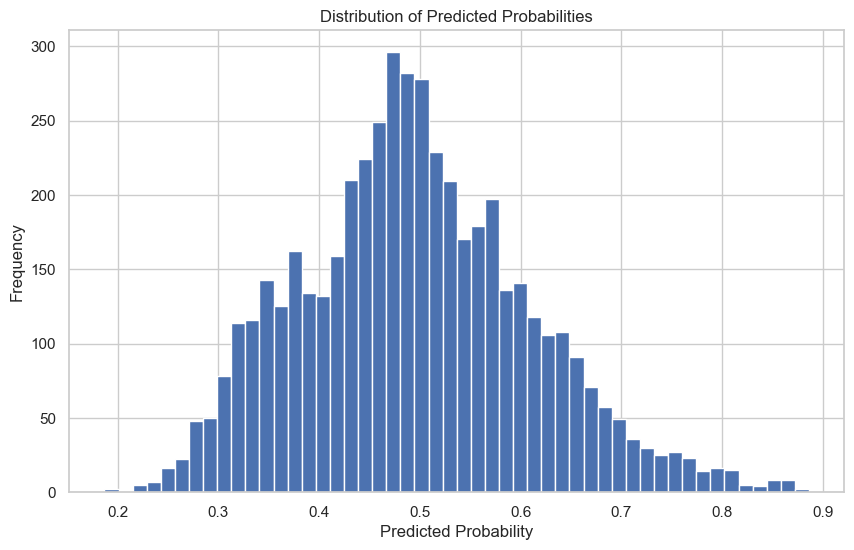

Enter 5 engine parameters separated by commas:  2.941605932,16.19386556,2.464503704,77.64093415,82.4457245


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted Engine Health Status: Unhealthy (Probability: 0.58)


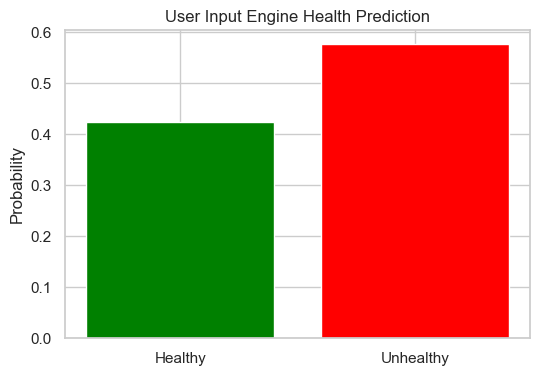

Enter 5 engine parameters separated by commas:  2.941605932,16.19386556,2.464503704,77.64093415,82.4457245


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted Engine Health Status: Unhealthy (Probability: 0.58)


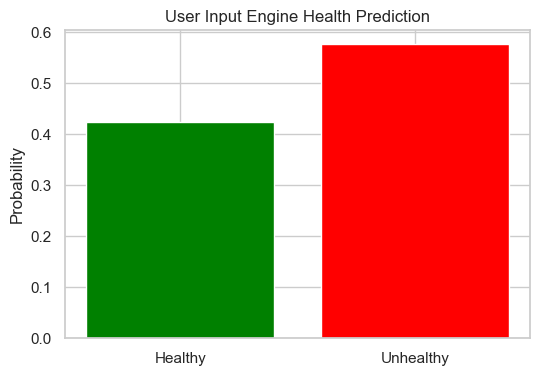

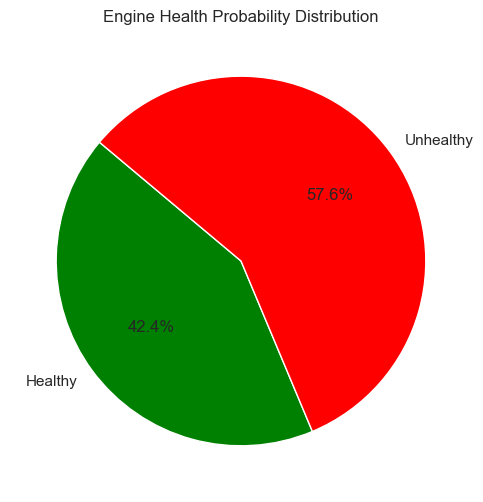

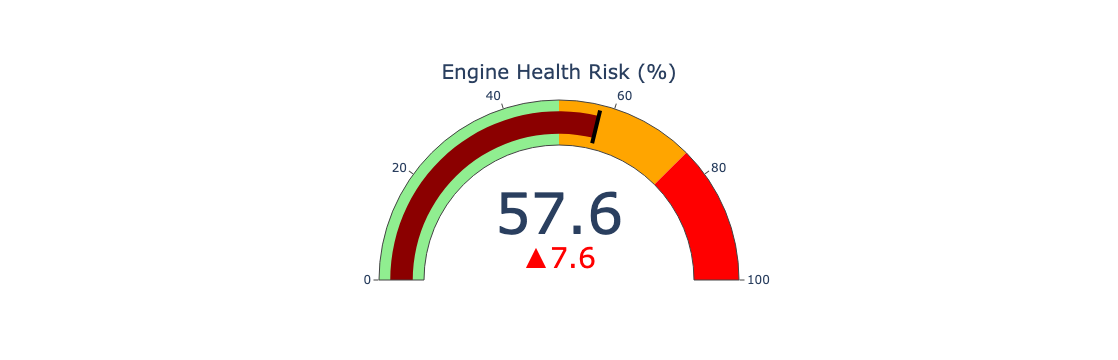

In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, Flatten, BatchNormalization, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Load the dataset
file_path ='/Users/saqlaintayab/Downloads/engine_data.csv'
df = pd.read_csv(file_path)

# Column-wise Analysis with Different Charts
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

def plot_column_analysis(df):
    for column in df.columns:
        plt.figure()
        if column == "Engine rpm":
            sns.lineplot(data=df[column], color='purple')
            plt.title(f'Line Plot of {column}')
        elif column == "Lub oil pressure":
            sns.boxplot(x=df[column], color='orange')
            plt.title(f'Box Plot of {column}')
        elif column == "Fuel pressure":
            sns.histplot(df[column], kde=True, color='skyblue', bins=30)
            plt.title(f'Histogram of {column}')
        elif column == "Coolant pressure":
            sns.violinplot(x=df[column], color='lightgreen')
            plt.title(f'Violin Plot of {column}')
        elif column == "lub oil temp":
            sns.stripplot(x=df[column], color='brown')
            plt.title(f'Strip Plot of {column}')
        elif column == "Coolant temp":
            sns.scatterplot(x=range(len(df[column])), y=df[column], color='red')
            plt.title(f'Scatter Plot of {column}')
        elif column == "Engine Condition":
            df[column].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
            plt.ylabel('')
            plt.title(f'Pie Chart of {column}')
        plt.tight_layout()
        plt.show()

plot_column_analysis(df)

# Define features and labels
X = df.drop(columns=["Engine rpm", "Engine Condition"]).values  # Drop non-sensor data
y = df["Engine Condition"].values  # Target variable

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle class imbalance using SMOTE
print("Original class distribution:", Counter(y))
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print("After SMOTE:", Counter(y_resampled))

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Reshape data for input
X_train_reshaped = np.expand_dims(X_train, axis=-1)
X_test_reshaped = np.expand_dims(X_test, axis=-1)

# Define Model Architectures
def build_cnn(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, kernel_size=3, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Conv1D(128, kernel_size=3, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    return Model(inputs, x)

def build_lstm(input_shape):
    inputs = Input(shape=input_shape)
    x = LSTM(128, return_sequences=False)(inputs)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    return Model(inputs, x)

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    x = Flatten()(inputs)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    return Model(inputs, x)

# Build Model
input_shape = (X.shape[1], 1)
cnn_model = build_cnn(input_shape)
lstm_model = build_lstm(input_shape)
transformer_model = build_transformer(input_shape)

combined = Concatenate()([cnn_model.output, lstm_model.output, transformer_model.output])
x = Dense(128, activation='relu')(combined)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=[cnn_model.input, lstm_model.input, transformer_model.input], outputs=outputs)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Implement Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    [X_train_reshaped, X_train_reshaped, X_train_reshaped], y_train, epochs=30, batch_size=32,
    validation_data=([X_test_reshaped, X_test_reshaped, X_test_reshaped], y_test),
    callbacks=[early_stopping], verbose=1
)

# Make predictions
y_pred_prob = model.predict([X_test_reshaped, X_test_reshaped, X_test_reshaped])

# Use default threshold of 0.5
best_threshold = 0.5
y_pred = (y_pred_prob > best_threshold).astype(int)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Plot distribution of predicted probabilities
plt.hist(y_pred_prob, bins=50)
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Probabilities")
plt.show()

# User Input for Prediction
try:
    user_input = list(map(float, input(f"Enter {X.shape[1]} engine parameters separated by commas: ").split(',')))
    if len(user_input) != X.shape[1]:
        raise ValueError(f"Expected {X.shape[1]} values, but got {len(user_input)}")
    user_input = np.array([user_input])
    user_scaled = scaler.transform(user_input)
    user_reshaped = np.expand_dims(user_scaled, axis=-1)

    prediction_prob = model.predict([user_reshaped, user_reshaped, user_reshaped])[0][0]
    predicted_status = "Healthy" if prediction_prob <= best_threshold else "Unhealthy"
    print(f"Predicted Engine Health Status: {predicted_status} (Probability: {prediction_prob:.2f})")

    # Graph for User Prediction
    plt.figure(figsize=(6, 4))
    plt.bar(["Healthy", "Unhealthy"], [1 - prediction_prob, prediction_prob], color=['green', 'red'])
    plt.title("User Input Engine Health Prediction")
    plt.ylabel("Probability")
    plt.show()
except ValueError as e:
    print(f"Invalid input: {e}")


import plotly.graph_objects as go
def show_gauge(probability):
    fig = go.Figure(go.Indicator(
        mode="gauge+number+delta",
        value=probability * 100,
        domain={'x': [0, 1], 'y': [0, 1]},
        title={'text': "Engine Health Risk (%)"},
        delta={'reference': 50, 'increasing': {'color': "red"}},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': "darkred" if probability > 0.5 else "green"},
            'steps': [
                {'range': [0, 50], 'color': 'lightgreen'},
                {'range': [50, 75], 'color': 'orange'},
                {'range': [75, 100], 'color': 'red'}
            ],
            'threshold': {
                'line': {'color': "black", 'width': 4},
                'thickness': 0.75,
                'value': probability * 100
            }
        }
    ))
    fig.show()

# User Input for Prediction
try:
    user_input = list(map(float, input(f"Enter {X.shape[1]} engine parameters separated by commas: ").split(',')))
    if len(user_input) != X.shape[1]:
        raise ValueError(f"Expected {X.shape[1]} values, but got {len(user_input)}")
    user_input = np.array([user_input])
    user_scaled = scaler.transform(user_input)
    user_reshaped = np.expand_dims(user_scaled, axis=-1)

    prediction_prob = model.predict([user_reshaped, user_reshaped, user_reshaped])[0][0]
    predicted_status = "Healthy" if prediction_prob <= best_threshold else "Unhealthy"
    print(f"Predicted Engine Health Status: {predicted_status} (Probability: {prediction_prob:.2f})")

    # 📊 Bar Chart
    plt.figure(figsize=(6, 4))
    plt.bar(["Healthy", "Unhealthy"], [1 - prediction_prob, prediction_prob], color=['green', 'red'])
    plt.title("User Input Engine Health Prediction")
    plt.ylabel("Probability")
    plt.show()

    # 🥧 Pie Chart
    plt.figure(figsize=(6, 6))
    plt.pie([1 - prediction_prob, prediction_prob], labels=["Healthy", "Unhealthy"],
            autopct='%1.1f%%', colors=["green", "red"], startangle=140)
    plt.title("Engine Health Probability Distribution")
    plt.show()

    # 🕹️ Speedometer Gauge
    show_gauge(prediction_prob)

except ValueError as e:
    print(f"Invalid input: {e}")


In [2]:
pip install "numpy<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 3.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.5
    Uninstalling numpy-2.2.5:
      Successfully uninstalled numpy-2.2.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install --upgrade pyarrow pandaspip install "numpy<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.8/30.8 MB 5.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 7.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 16.1.0
    Uninstalling pyarrow-16.1.0:
      Successfully uninstalled pyarrow-16.1.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
Note: you may need to restart the kernel to use updated packages.
